# Análise de qualidade

Iremos entender algumas métricas utilizadas para medir a qualidade de um modelo de detecção de objetos. Primeiramente, é importante entender alguns parâmetros relevantes do cálculo de qualidade:

* **conf**: Limiar de probabilidade que uma caixa prevista pelo modelo é considerada como uma detecção genuína
* **IoU (nms)**: Parâmetro utilizado pela supressão de não-máximos para remoção de caixas espúrias com alto IoU. Esse IoU é calculado apenas para as caixas previstas pelo modelo.
* **IoU (gt)**: IoU calculado entre as caixas previstas e as caixas padrão ouro anotadas manualmente. Apenas caixas previstas pelo modelo com IoU acima de um limiar com uma anotação são consideradas como previsões corretas. Por exemplo, podemos considerar que uma caixa prevista com IoU de 0.6 com uma caixa anotada é um previsão correta, mesmo que a caixa não esteja exatamente na mesma posição. Podemos, por exemplo, ser mais rigorosos e considerar que apenas caixas com IoU acima de 0.9 sejam consideradas corretas.

In [10]:
from pathlib import Path
from ultralytics import YOLO

root = Path("runs/detect/aquarium_results")
train_root = root / "train"
val_root = root / "val"

# Caminho do modelo treinado
model = YOLO(train_root / "weights" / "best.pt")
dataset_yaml = "../data/aquarium/data.yaml"

metrics = model.val(
    data=dataset_yaml,
    imgsz=640,
    batch=16,
    # Na validação, é usado o valor 0.001 para conf para que valores de precisão, recall e AP sejam 
    # calculados para uma ampla gama de limiares de confiança, indo de 0.001 a 1.0.
    conf=0.001,
    # O parâmetro iou (nms) é ignorado para o modelo YOLO26, que não utiliza NMS tradicional, mas é
    # importante para outros modelos
    iou=0.7,
    device="cuda",
    project="aquarium_results",
    name="val",
)

Ultralytics 8.4.48 🚀 Python-3.14.4 torch-2.10.0 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11908MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10851.8±613.3 MB/s, size: 481.2 KB)
val: Scanning /home/chcomin/Dropbox/ufscar/visao_computacional/repositorio/data/aquarium/labels/val.cache... 127 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 88.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.5it/s 1.8s0.8ss
                   all        127        909       0.84      0.658      0.741      0.425
                  fish         63        459      0.803      0.702      0.775      0.405
             jellyfish          9        155      0.869      0.884      0.925      0.516
               penguin         17        104      0.751      0.683      0.696      0.301
                puffin         15         74      0.839      0.486      0.6

## Métricas de treinamento

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd


df_results = pd.read_csv(train_root / "results.csv")
print("Tabela contendo as métricas durante o treinamento: ")
df_results.head()

Tabela contendo as métricas durante o treinamento: 


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,8.77279,3.56729,5.41093,0.02285,0.00021,0.02116,0.00004,0.00001,4.02506,3.78127,0.03612,0.008100,0.002700,0.008100,0.002700,0.008100,0.002700,0.008100,0.002700
1,2,12.13750,2.82251,5.12666,0.01647,0.00089,0.01518,0.00016,0.00003,3.73969,3.77547,0.03135,0.016492,0.005497,0.016492,0.005497,0.016492,0.005497,0.016492,0.005497
2,3,15.30850,2.50199,4.69958,0.01376,0.00434,0.19390,0.00618,0.00237,2.50802,3.68805,0.01762,0.024875,0.008292,0.024875,0.008292,0.024875,0.008292,0.024875,0.008292
3,4,18.31980,2.36184,4.22771,0.01233,0.76986,0.05288,0.04347,0.01500,2.10101,3.23616,0.01361,0.029955,0.009985,0.029955,0.009985,0.029955,0.009985,0.029955,0.009985
4,5,21.26670,2.19528,3.83717,0.01087,0.51252,0.07284,0.05148,0.01615,2.02433,3.30198,0.01299,0.029941,0.009980,0.029941,0.009980,0.029941,0.009980,0.029941,0.009980


Plots de métricas durante o treinamento: 


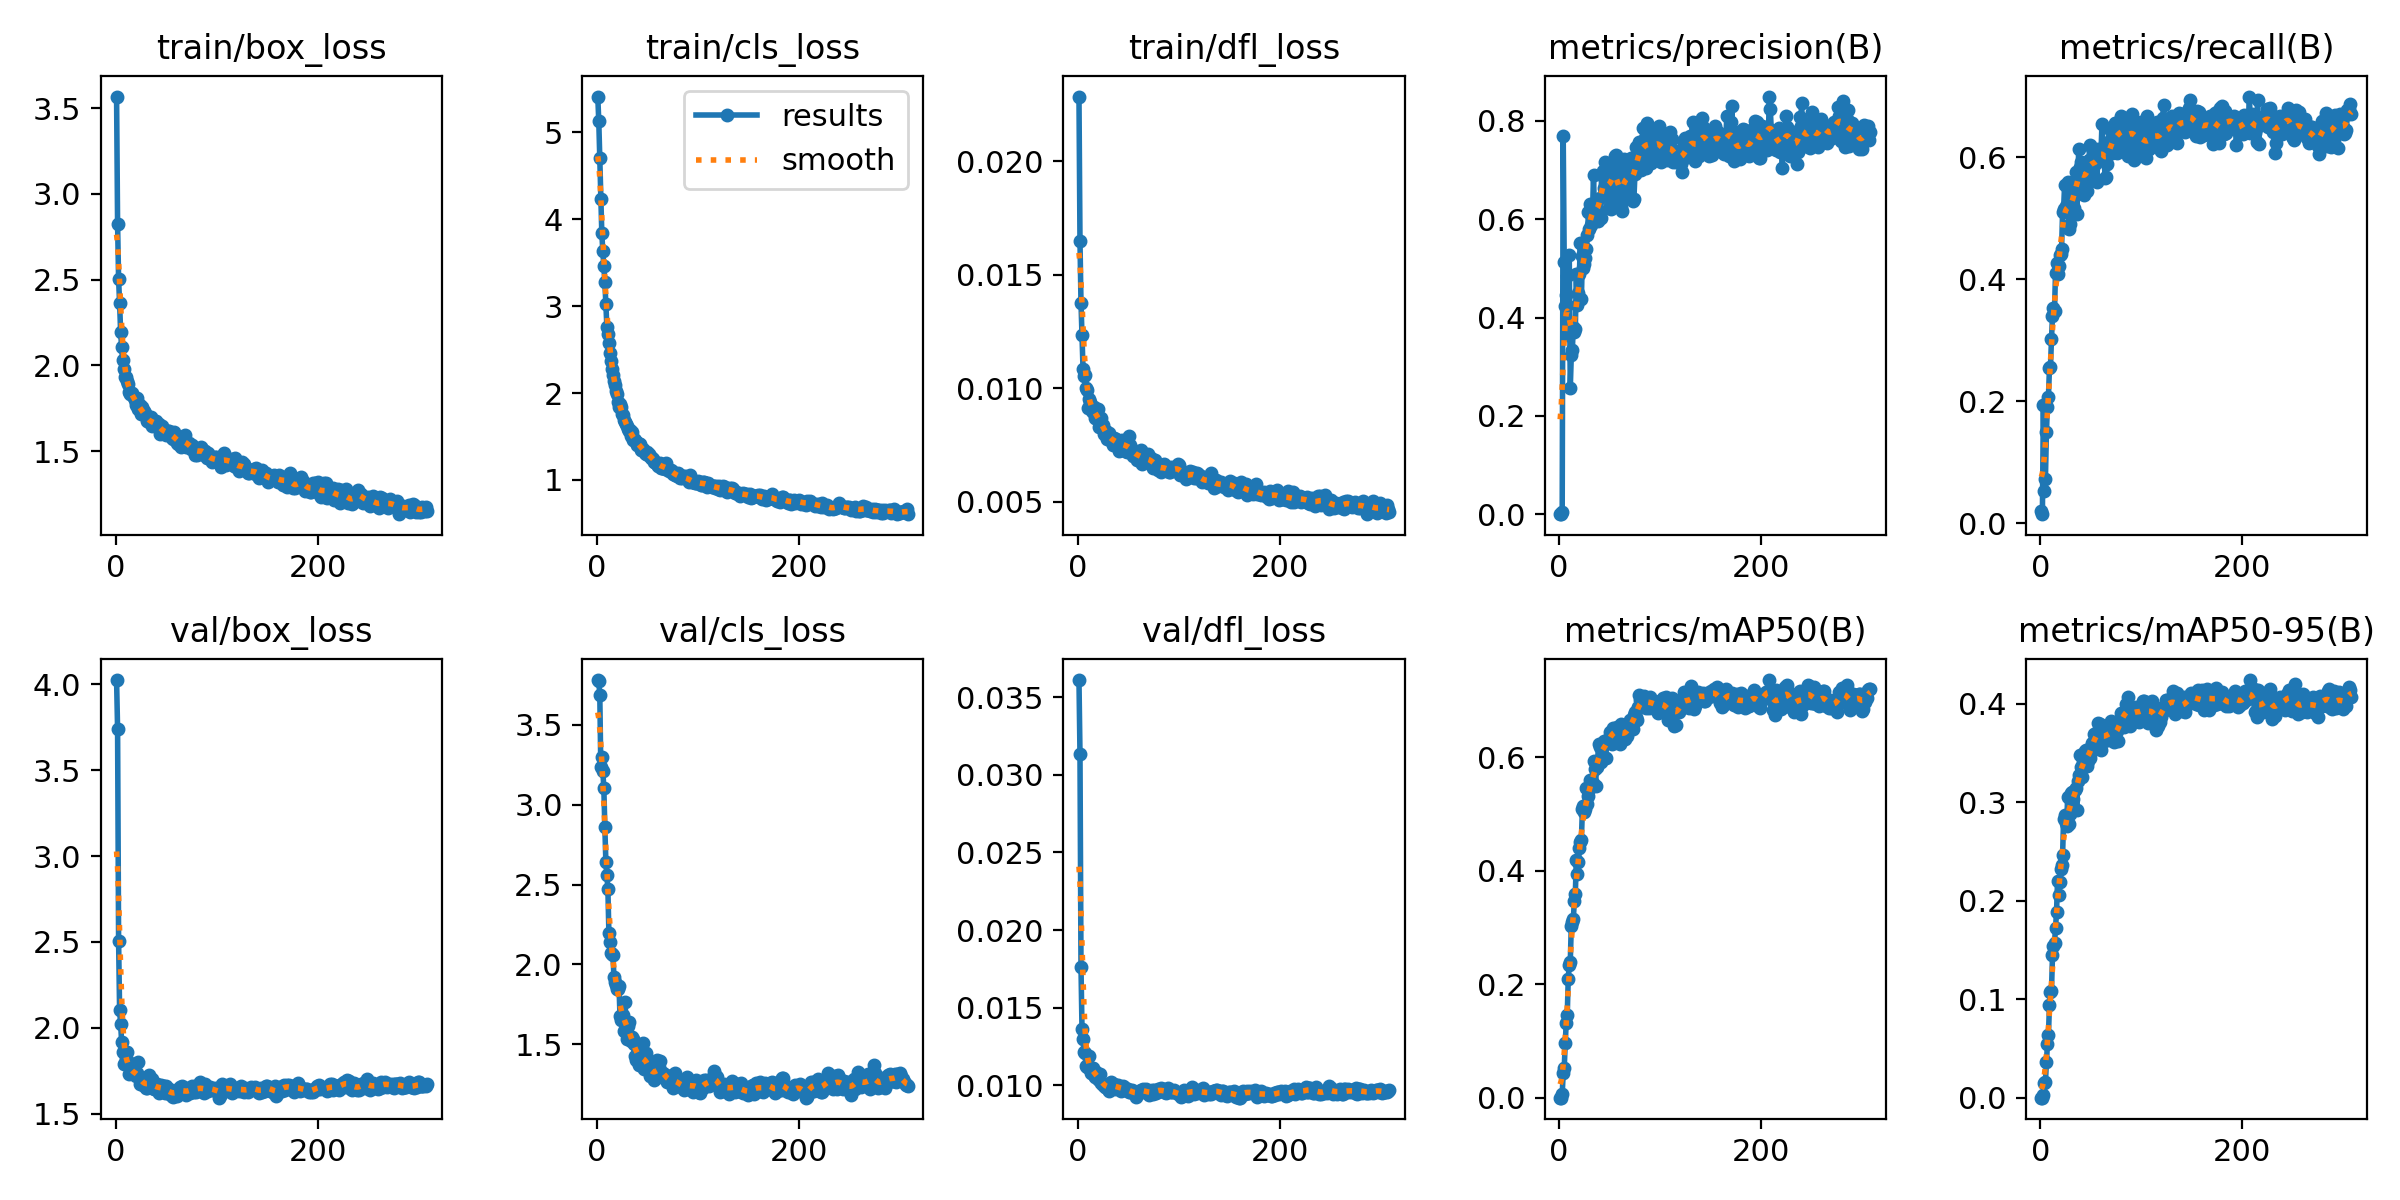

In [12]:
print("Plots de métricas durante o treinamento: ")
Image.open(train_root / "results.png")

## Matriz de confusão

Para o cálculo da matriz de confusão, a biblioteca ultralytics utiliza o valor conf=0.25 caso o valor conf=0.001 tenha sido passado para a função model.val! O valor 0.25 também é utilizado caso conf não tenha sido
passado. Adicionalmente, apenas caixas com iou (gt) acima de 0.45 com o ground truth são consideradas verdadeiros positivos.

[[        345           0           1           0           6           1           1         107]
 [          0         139           0           0           0           0           0          30]
 [          0           0          81           0           0           2           0          38]
 [          0           0           0          40           0           1           0          10]
 [          5           0           0           0          36           0           0          10]
 [          1           0           0           0           0          15           0           0]
 [          1           0           0           0           0           0          25           5]
 [        107          16          22          34          15           8           7           0]]


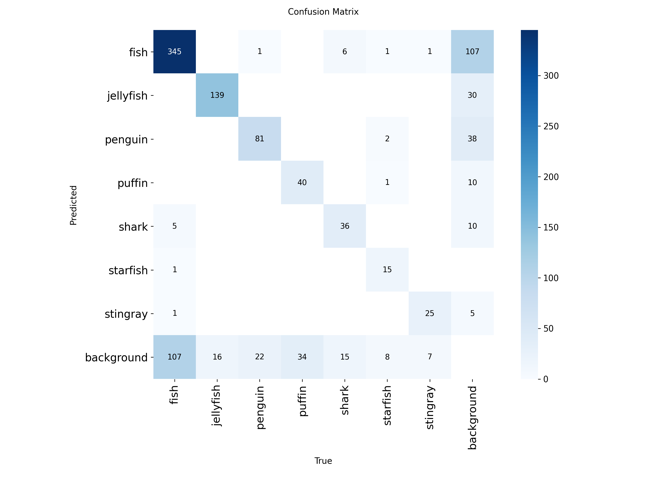

In [13]:
print(metrics.confusion_matrix.matrix)

Image.open(val_root / "confusion_matrix.png").resize((650, 500))

## Curvas de precisão, revocação e F1

Essas curvas indicam a fração de falsos positivos e negativos conforme o limiar de confiança (probabilidade) é alterado.

Importante! As curvas são calculadas para um limiar de IoU (gt) de 0.5 com as caixas padrão ouro (anotadas manualmente).

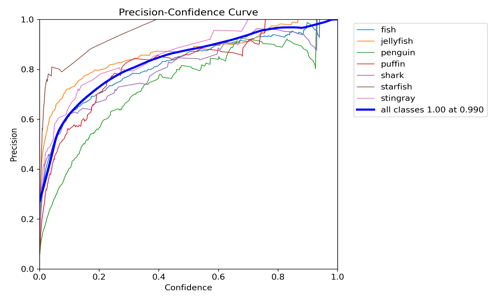

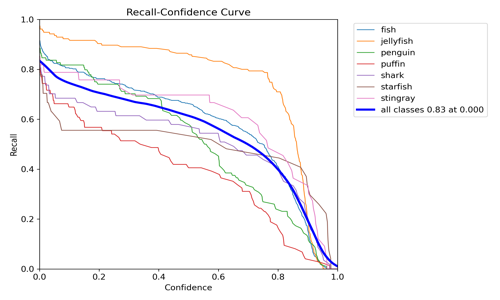

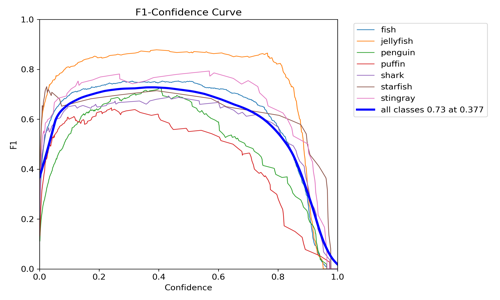

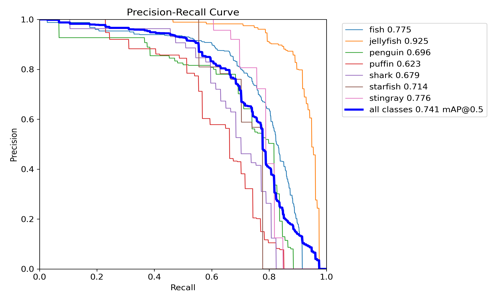

In [14]:
rec, prec, *_ = metrics.curves_results[0]
conf, f1, *_ = metrics.curves_results[1]
conf, prec, *_ = metrics.curves_results[2]
conf, rec, *_ = metrics.curves_results[3]

display(
    Image.open(val_root / "BoxP_curve.png").resize((500, 300)),
    Image.open(val_root / "BoxR_curve.png").resize((500, 300)),
    Image.open(val_root / "BoxF1_curve.png").resize((500, 300)),
    Image.open(val_root / "BoxPR_curve.png").resize((500, 300))
)

O valor mostrado na legenda do último gráfico (precision-recall) para cada classe indica a área abaixo da curva, chamada de Average Precision (AP). Quanto maior essa área, melhor o modelo. 

A curva azul grossa representa a média das curvas das classes, e a sua área é chamada de mAP (mean Average Precision).

Um possível valor ótimo de confiança pode ser definido pelo pico do gráfico do escore F1. O valor ótimo de confiança é mostrado no gráfico das curvas F1 (all classes <F1 ótimo> at <conf ótimo>)

In [59]:
print("Valores de precisão, revocação e F1 para uma confiança ótima (IoU 0.5):")
print(metrics.box.p)
print(metrics.box.r)
print(metrics.box.f1)

Valores de precisão, revocação e F1 para uma confiança ótima (IoU 0.5):
[    0.80283     0.86855     0.75109     0.83918     0.77882     0.99222     0.84609]
[    0.70153     0.88387     0.68269     0.48649     0.59649     0.55556     0.69697]
[    0.74877     0.87614     0.71526     0.61592     0.67557     0.71229     0.76432]


Os valores de precisão e revocação acima são mostrados na tabela de resumo retornada ao chamar o método model.val() (no começo deste notebook).

Um grande desafio é resumir as métricas em um único valor para podermos medir a qualidade do modelo. Os seguintes parâmetros precisam ser levados em consideração:

* Limiar de confiança para considerar uma predição como sendo válida
* IoU (gt) utilizado para considerar uma caixa associada a uma anotação manual
* Agregação entre as diferentes classes do dataset

O primeiro passo é definir um conjunto de IoUs a serem testados. O padrão é definir os seguintes 10 valores de limiar:

`iou_t = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]`

Curvas precision-recall são calculadas para cada um desses limiares e para cada classe, e a área sob a curva é calculada para cada caso, gerando os valores de Average Precision (AP):

In [68]:
all_ap = metrics.box.all_ap
print("Valores de AP para cada classe e IoU:")
print(all_ap)
print(f"Número de classes: {all_ap.shape[0]}. Número de limiares de IoU: {all_ap.shape[1]}.")

Valores de AP para cada classe e IoU:
[[    0.77524     0.73905     0.67996     0.57941     0.49222     0.36279     0.24927     0.10594    0.058681   0.0060006]
 [    0.92543     0.89648     0.85677     0.77505     0.69656     0.50148     0.31889     0.15063    0.033429      0.0066]
 [    0.69624      0.6387     0.53368     0.43879     0.32897     0.22351      0.1143     0.02036   0.0075839   0.0047702]
 [    0.62339     0.50477     0.47514     0.42968     0.35349     0.24737      0.1472    0.077823   0.0038333           0]
 [    0.67874     0.64696     0.63211     0.58362     0.53992     0.40638      0.3641     0.19115    0.098495   0.0085782]
 [    0.71393     0.71393     0.61813     0.61569     0.51246     0.50791     0.42513     0.35036     0.22369       0.154]
 [    0.77643     0.77643     0.77643     0.77643     0.77643     0.67108     0.44163     0.38125     0.24893    0.035349]]
Número de classes: 7. Número de limiares de IoU: 10.


A partir desses valores é calculada a média de cada classe para os IoUs considerados:

In [92]:
ap_50_95 = all_ap.mean(axis=1)

print(f"AP50-95: {ap_50_95}")

AP50-95: [    0.40486     0.51613     0.30069     0.28627     0.41501     0.48352     0.56604]


E a média de AP50-95 para todas as classes é o valor final de performance:

In [93]:
map_50_095 = ap_50_95.mean()
print(f"mAP50-95: {map_50_095}")

mAP50-95: 0.4246452110823221
